# Task 3 — Exploratory Data Analysis

**Goal:** Visualize feature distributions by class, identify and remove highly correlated features, and rank features by their ability to separate active from inactive compounds.

**Input:** `data/processed/X_scaled.npy`, `y.npy`, `cid.npy`, `compounds_clean.csv`  
**Output:** `data/processed/X_scaled.npy` (updated, correlation-filtered), `data/processed/feature_names.npy`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Data

In [2]:
X = np.load('../data/processed/X_scaled.npy')
y = np.load('../data/processed/y.npy')
cid = np.load('../data/processed/cid.npy')

df_clean = pd.read_csv('../data/processed/compounds_clean.csv')
feature_names = [c for c in df_clean.columns if c not in ['CID', 'Class']]

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}  — classes: {np.unique(y)}')
print(f'Features     : {len(feature_names)}')

X shape      : (243, 311)
y shape      : (243,)  — classes: [0 1]
Features     : 311


## 2. Class-Split Feature Distributions

Box plots of 12 representative features split by class label. Features where the two boxes barely overlap are strong candidates for the classifier.

/var/folders/cp/29s94x0s7c71s6_qytw80tf00000gn/T/ipykernel_22150/2588559441.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inactive, active], labels=['Inactive (0)', 'Active (1)'],
/var/folders/cp/29s94x0s7c71s6_qytw80tf00000gn/T/ipykernel_22150/2588559441.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inactive, active], labels=['Inactive (0)', 'Active (1)'],
/var/folders/cp/29s94x0s7c71s6_qytw80tf00000gn/T/ipykernel_22150/2588559441.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inactive, active], labels=['Inactive (0)', 'Active (1)'],
/var/folders/cp/29s94x0s7c71

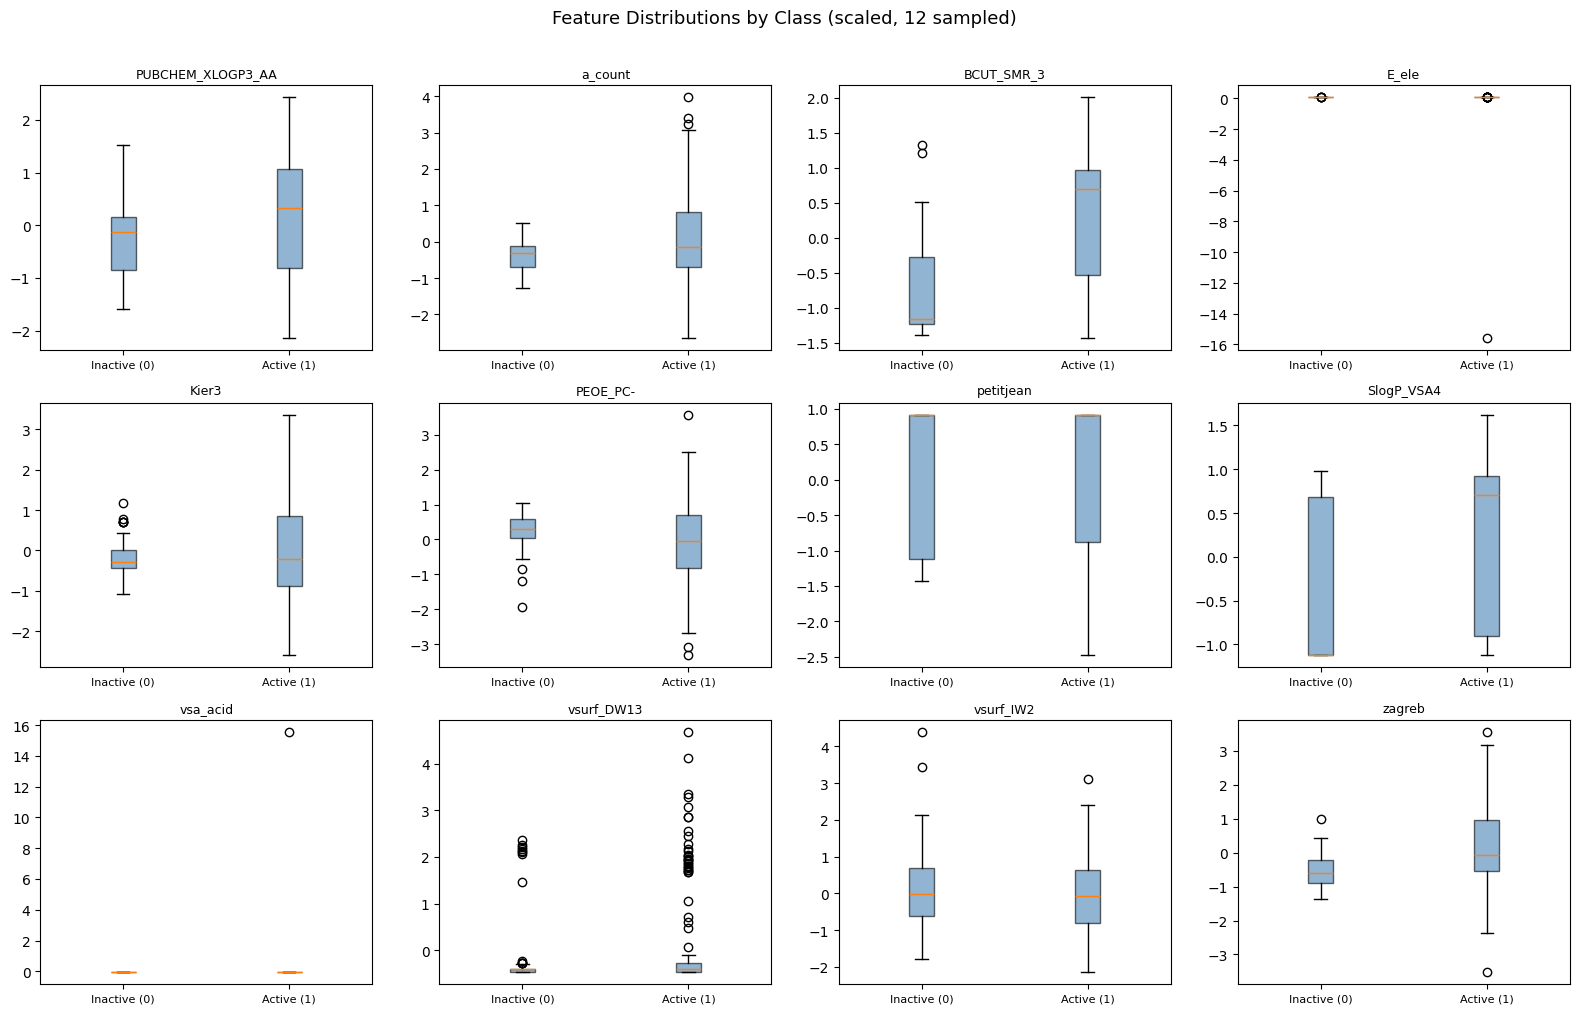

In [3]:
df_plot = pd.DataFrame(X, columns=feature_names)
df_plot['Class'] = y

# Pick 12 evenly spaced features as a representative sample
sample_features = [feature_names[i] for i in np.linspace(0, len(feature_names) - 1, 12, dtype=int)]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for ax, feat in zip(axes, sample_features):
    inactive = df_plot.loc[df_plot['Class'] == 0, feat]
    active   = df_plot.loc[df_plot['Class'] == 1, feat]
    ax.boxplot([inactive, active], labels=['Inactive (0)', 'Active (1)'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(feat[:20], fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Feature Distributions by Class (scaled, 12 sampled)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Analysis

Many molecular descriptors are mathematically related (e.g. molecular weight and atom count). Highly correlated features carry redundant information and can destabilize the SVC decision boundary. We visualise the top 40 most inter-correlated features before pruning.

Features with at least one correlation > 0.95: 113


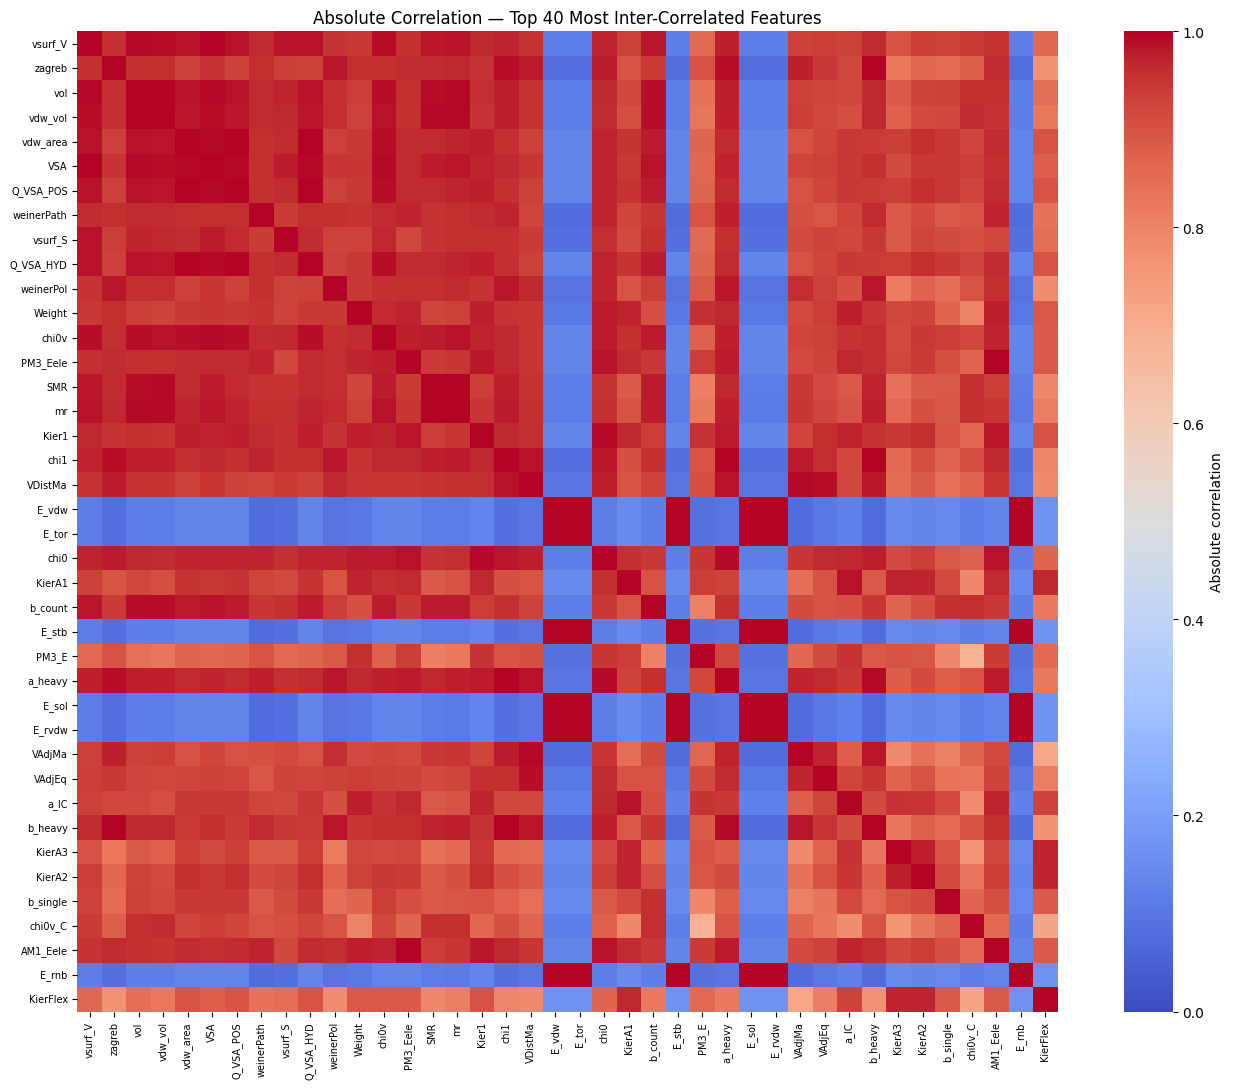

In [4]:
df_features = pd.DataFrame(X, columns=feature_names)
corr_matrix = df_features.corr().abs()

# Find the 40 features involved in the most high-correlation pairs (r > 0.95)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_counts = (upper > 0.95).sum(axis=0).sort_values(ascending=False)
top_corr_features = high_corr_counts[high_corr_counts > 0].head(40).index.tolist()

print(f'Features with at least one correlation > 0.95: {(high_corr_counts > 0).sum()}')

fig, ax = plt.subplots(figsize=(14, 11))
subset_corr = corr_matrix.loc[top_corr_features, top_corr_features]
sns.heatmap(subset_corr, ax=ax, cmap='coolwarm', vmin=0, vmax=1,
            xticklabels=True, yticklabels=True,
            linewidths=0, square=True, cbar_kws={'label': 'Absolute correlation'})
ax.set_title('Absolute Correlation — Top 40 Most Inter-Correlated Features', fontsize=12)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig('../results/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Remove Highly Correlated Features

For each pair of features with |r| > 0.95, we drop the second feature encountered (upper-triangle traversal). This is a greedy but effective approach that keeps one representative from each correlated cluster.

In [5]:
threshold = 0.95

to_drop = set()
for col in upper.columns:
    if col in to_drop:
        continue
    correlated_cols = upper.index[upper[col] > threshold].tolist()
    to_drop.update(correlated_cols)

keep_features = [f for f in feature_names if f not in to_drop]

print(f'Correlation threshold : {threshold}')
print(f'Features before       : {len(feature_names)}')
print(f'Features dropped      : {len(to_drop)}')
print(f'Features remaining    : {len(keep_features)}')

Correlation threshold : 0.95
Features before       : 311
Features dropped      : 105
Features remaining    : 206


In [6]:
keep_idx = [feature_names.index(f) for f in keep_features]
X_filtered = X[:, keep_idx]

print(f'X shape before: {X.shape}')
print(f'X shape after : {X_filtered.shape}')

X shape before: (243, 311)
X shape after : (243, 206)


## 5. Univariate Feature Ranking

Mann-Whitney U test measures whether the distribution of a feature differs significantly between active and inactive compounds — without assuming normality. Lower p-value = stronger class separation.

In [7]:
active_mask   = y == 1
inactive_mask = y == 0

pvals = []
for i, feat in enumerate(keep_features):
    stat, p = mannwhitneyu(X_filtered[active_mask, i],
                           X_filtered[inactive_mask, i],
                           alternative='two-sided')
    pvals.append(p)

ranking = pd.DataFrame({'feature': keep_features, 'p_value': pvals})
ranking = ranking.sort_values('p_value').reset_index(drop=True)

print('Top 20 most discriminative features (Mann-Whitney U):')
print(ranking.head(20).to_string(index=False))

Top 20 most discriminative features (Mann-Whitney U):
     feature  p_value
 GCUT_PEOE_1   0.0000
   MNDO_LUMO   0.0000
    PM3_LUMO   0.0000
    SMR_VSA3   0.0000
  PEOE_VSA-4   0.0000
        logS   0.0000
  GCUT_SMR_3   0.0000
   vsa_other   0.0000
     MNDO_HF   0.0000
PEOE_VSA_NEG   0.0000
  SlogP_VSA0   0.0000
  PEOE_VSA-3   0.0000
        a_nO   0.0000
     vsa_pol   0.0000
       chi1v   0.0000
PEOE_VSA_POL   0.0000
  BCUT_SMR_3   0.0000
   b_max1len   0.0000
  SlogP_VSA5   0.0000
  GCUT_SMR_1   0.0000


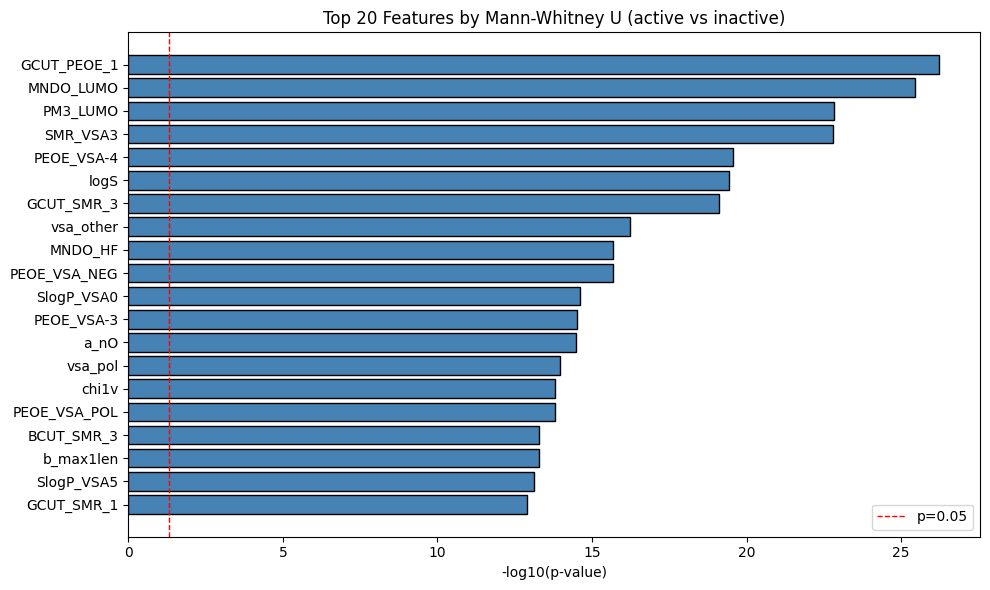

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
top20 = ranking.head(20)
ax.barh(top20['feature'][::-1], -np.log10(top20['p_value'][::-1]),
        color='steelblue', edgecolor='black')
ax.axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
ax.set_xlabel('-log10(p-value)')
ax.set_title('Top 20 Features by Mann-Whitney U (active vs inactive)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Updated Feature Set

In [9]:
np.save('../data/processed/X_scaled.npy', X_filtered)
np.save('../data/processed/feature_names.npy', np.array(keep_features))

print('Saved:')
print(f'  data/processed/X_scaled.npy      {X_filtered.shape}  (overwritten with filtered features)')
print(f'  data/processed/feature_names.npy {np.array(keep_features).shape}')

Saved:
  data/processed/X_scaled.npy      (243, 206)  (overwritten with filtered features)
  data/processed/feature_names.npy (206,)
